# Understanding Transformer

---

**학습 목표**
- RNN/LSTM의 한계를 이해한다
- Transformer의 핵심 구조를 이해한다
- Attention Mechanism을 이해한다
- Positional Encoding, Encoder Block을 이해한다.

---
### 0. Install libraries

In [1]:
# !pip install torch numpy matplotlib seaborn tqdm
# 라이브러리가 설치되어 있지 않다면 위 명령어로 설치하세요.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
import itertools
import math
from tqdm import tqdm
from IPython.display import display, HTML

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

np.set_printoptions(linewidth=np.inf) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f'PyTorch: {torch.__version__}')
print(f'Using device: {device}')

PyTorch: 2.9.1+cu126
Using device: cuda


---

### 1. Tokenization and Embedding

- Token: 고정된 어휘 집합에 매핑되는 최소 입력 단위
- Tokenization: 텍스트, 이미지, 오디오 클립, 동영상 등 다양한 형태의 데이터를 처리할 때 데이터를 토큰으로 변환시키는 과정
- Embedding: 객체를 연속 공간의 벡터에 매핑함으로써 의미적 관계와 유사성을 수치적으로 표현하는 함수 또는 그 결과

In [3]:
vocab = {
    '<PAD>': 0, '<SOS>': 1, '<EOS>': 2,
    'I': 3, 'you': 4,                   # 주어
    'like': 5, 'love': 6, 'hate': 7,    # 감정
    'cats': 8, 'dogs': 9, "me": 10,      # 대상
    'really': 11, 'not': 12, 'do': 13,
    '?': 14
}
idx2word = {v: k for k, v in vocab.items()}

VOCAB_SIZE = len(vocab)   # 15
D_MODEL    = 8           # 임베딩 차원
MAX_SEQ    = 9

subjects = ['I', 'you', 'cats', 'dogs']
negations = [None, 'not']
intensifiers = [None, 'really']
verbs = ['like', 'love', 'hate']
objects = ['cats', 'dogs', 'you', 'me']
is_question = [False, True]

sentences = []

# 데이터셋 생성
for s, n, r, v, o, q in itertools.product(subjects, negations, intensifiers, verbs, objects, is_question):
    tokens = ['<SOS>'] # 시작은 <SOS>로 시작합니다.

    if q:
        tokens.append('do')

    tokens.append(s)

    if n:
        if not q : tokens.append('do')
        tokens.append(n)
    if r:
        tokens.append(r)

    tokens.append(v)
    if (o != s) and not (o == "me" and s == "I"):
        tokens.append(o)
    else:
        continue

    if q:
        tokens.append('?')
    tokens.append('<EOS>') # 끝은 <EOS>로 끝납니다.
    
    token_ids = [vocab[t] for t in tokens]
    token_ids += [vocab['<PAD>']] * (MAX_SEQ - len(token_ids)) # 남은 부분은 <PAD>로 채웁니다.
    
    sentences.append(token_ids)

batch_tokens = torch.tensor(sentences, dtype=torch.long)

print(f'shape: {batch_tokens.shape}')

print('\n문장')
for i, row in enumerate(batch_tokens[:]):
    words = [idx2word[t.item()] for t in row]
    print(f'{i+1:<4}: {" ".join(words)}')

shape: torch.Size([288, 9])

문장
1   : <SOS> I like cats <EOS> <PAD> <PAD> <PAD> <PAD>
2   : <SOS> do I like cats ? <EOS> <PAD> <PAD>
3   : <SOS> I like dogs <EOS> <PAD> <PAD> <PAD> <PAD>
4   : <SOS> do I like dogs ? <EOS> <PAD> <PAD>
5   : <SOS> I like you <EOS> <PAD> <PAD> <PAD> <PAD>
6   : <SOS> do I like you ? <EOS> <PAD> <PAD>
7   : <SOS> I love cats <EOS> <PAD> <PAD> <PAD> <PAD>
8   : <SOS> do I love cats ? <EOS> <PAD> <PAD>
9   : <SOS> I love dogs <EOS> <PAD> <PAD> <PAD> <PAD>
10  : <SOS> do I love dogs ? <EOS> <PAD> <PAD>
11  : <SOS> I love you <EOS> <PAD> <PAD> <PAD> <PAD>
12  : <SOS> do I love you ? <EOS> <PAD> <PAD>
13  : <SOS> I hate cats <EOS> <PAD> <PAD> <PAD> <PAD>
14  : <SOS> do I hate cats ? <EOS> <PAD> <PAD>
15  : <SOS> I hate dogs <EOS> <PAD> <PAD> <PAD> <PAD>
16  : <SOS> do I hate dogs ? <EOS> <PAD> <PAD>
17  : <SOS> I hate you <EOS> <PAD> <PAD> <PAD> <PAD>
18  : <SOS> do I hate you ? <EOS> <PAD> <PAD>
19  : <SOS> I really like cats <EOS> <PAD> <PAD> <PAD>
20  : <SOS

In [4]:
embedding_layer = nn.Embedding(VOCAB_SIZE, D_MODEL) # 임베딩 레이어 생성 (모델 내부에 임베딩 테이블이 생성됩니다.)
embedding_layer.eval()

embedded = embedding_layer(batch_tokens)

print(f'임베딩 테이블 shape: {embedding_layer.weight.shape}')
print(f'임베딩 출력 shape: {embedded.shape}')

print('\n=== 문장1의 토큰별 임베딩 벡터 ===')
print(f'{"Token":<10} {"Embedding Vector"}' )
print('-' * 80)
for i, tok in enumerate(batch_tokens[0]):
    vec = embedded[0, i].detach().numpy()
    print(f'{idx2word[tok.item()]:<10} {np.round(vec, 4)}')

print('\n이는 학습되지 않은 랜덤한 임베딩입니다.')

임베딩 테이블 shape: torch.Size([15, 8])
임베딩 출력 shape: torch.Size([288, 9, 8])

=== 문장1의 토큰별 임베딩 벡터 ===
Token      Embedding Vector
--------------------------------------------------------------------------------
<SOS>      [-0.7521  1.6487 -0.3925 -1.4036 -0.7279 -0.5594 -0.7688  0.7624]
I          [ 1.2791  1.2964  0.6105  1.3347 -0.2316  0.0418 -0.2516  0.8599]
like       [-1.5576  0.9956 -0.8798 -0.6011 -1.2742  2.1228 -1.2347 -0.4879]
cats       [ 1.4451  0.8564  2.2181  0.5232  0.3466 -0.1973 -1.0546  1.278 ]
<EOS>      [ 1.6423 -0.1596 -0.4974  0.4396 -0.7581  1.0783  0.8008  1.6806]
<PAD>      [ 1.9269  1.4873  0.9007 -2.1055  0.6784 -1.2345 -0.0431 -1.6047]
<PAD>      [ 1.9269  1.4873  0.9007 -2.1055  0.6784 -1.2345 -0.0431 -1.6047]
<PAD>      [ 1.9269  1.4873  0.9007 -2.1055  0.6784 -1.2345 -0.0431 -1.6047]
<PAD>      [ 1.9269  1.4873  0.9007 -2.1055  0.6784 -1.2345 -0.0431 -1.6047]

이는 학습되지 않은 랜덤한 임베딩입니다.


---

### 2. RNN

#### 1. RNN (Recurrent Neural Network)
RNN은 이전 시점의 정보를 현재 시점으로 전달하여 시계열 데이터를 처리하는 기본적인 구조입니다.

##### 수식
$$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b)$$

* **$h_{t-1} \to h_t$**: 이전 상태에 가중치를 곱하고 활성화 함수를 거쳐 업데이트됩니다.
* **구조적 특징**: 정보가 매 시점 '곱셈' 연산을 통해 전달됩니다.

#### 2. LSTM (Long Short-Term Memory)
LSTM은 RNN의 단기 기억 문제를 해결하기 위해 'Cell State'라는 별도의 정보 통로를 도입했습니다.

##### 수식 (핵심 게이트)
1.  **Forget Gate ($f_t$):** 과거 정보를 얼마나 버릴지 결정
    $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2.  **Cell State Update ($C_t$):** **(핵심)** 덧셈 기반의 정보 전달
    $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
3.  **Hidden State ($h_t$):** 최종 출력 결정
    $$h_t = o_t \odot \tanh(C_t)$$


=== SAMPLE SENTENCES ===
A: <SOS> I like cats <EOS> <PAD> <PAD> <PAD> <PAD>
First change: <SOS> you like cats <EOS> <PAD> <PAD> <PAD> <PAD>
Last  change: <SOS> I like dogs <EOS> <PAD> <PAD> <PAD> <PAD>

=== 영향 비교 ===
첫 토큰 변경 영향: 0.000032
마지막 토큰 변경 영향: 0.000685
→ 마지막 토큰이 약 21.3배 더 영향 큼

LSTM - 첫 토큰 변경 영향: 0.002411
LSTM - 마지막 토큰 변경 영향: 0.007650
→ LSTM: 마지막 토큰이 약 3.2배 더 영향 큼


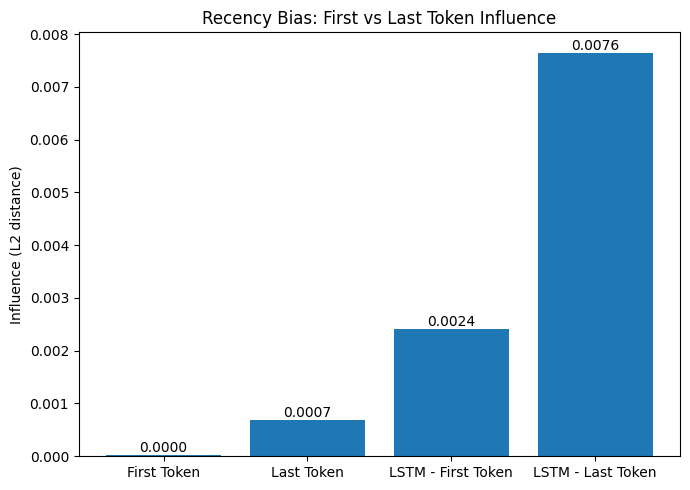

학습되지 않은 임베딩과 RNN, LSTM을 사용하여, 결과가 의미 정보를 반영하지 못할 수 있습니다.

그러나 hidden state는 순차적으로 누적되면서 Jacobian이 곱해져 초기 정보가 감쇠됨을 확인할 수 있습니다.
이는 recency bias가 존재함을 시사합니다.

RNN의 단순 재귀 구조가 가지는 정보 손실을 LSTM의 게이트 메커니즘이 효과적으로 억제하고 있음을 정량적 수치로 확인할 수 있습니다.
그럼에도 LSTM도 여전히 마지막 토큰이 첫 토큰보다 더 큰 영향을 미치는 것을 볼 수 있습니다.

Attention 메커니즘을 통해 모든 토큰이 직접적으로 연결되는 트랜스포머에서는 이러한 recency bias가 어떻게 달라지는지 다음 단계에서 살펴보겠습니다.


In [5]:
rnn = nn.RNN(D_MODEL, 4, batch_first=True)
lstm = nn.LSTM(D_MODEL, 4, batch_first=True)

rnn.eval()
lstm.eval()

test_length = 1

# 토큰을 문장으로 디코딩합니다.
def decode(tokens):
    return [idx2word[t.item()] for t in tokens]

# 특정 위치의 토큰을 변경하는 함수입니다.
def perturb(tokens, pos, t):
    tokens_B = tokens.clone()
    original = tokens_B[pos].item()
    tokens_B[pos] = (original + t) % VOCAB_SIZE
    return tokens_B

# 처음 토큰과 마지막 토큰을 변경하여 hidden state에 미치는 영향을 비교해봅시다.
print("\n=== SAMPLE SENTENCES ===")
for i in range(test_length):
    sent = batch_tokens[i]
    print(f"A: {' '.join(decode(sent))}")

    sent_first = perturb(sent, 1, 1)
    sent_last  = perturb(sent, 3, 1)

    print(f"First change: {' '.join(decode(sent_first))}")
    print(f"Last  change: {' '.join(decode(sent_last))}")
    print()

def measure_diff(tokens, pos, t):
    tokens_A = tokens.clone()
    tokens_B = perturb(tokens.clone(), pos, t)

    x_A = embedding_layer(tokens_A.unsqueeze(0))
    x_B = embedding_layer(tokens_B.unsqueeze(0))

    with torch.no_grad():
        _, h_A = rnn(x_A)
        _, h_B = rnn(x_B)

    return (h_B - h_A).norm().item()

def measure_diff_lstm(tokens, pos, t):
    tokens_A = tokens.clone()
    tokens_B = perturb(tokens.clone(), pos, t)

    x_A = embedding_layer(tokens_A.unsqueeze(0))
    x_B = embedding_layer(tokens_B.unsqueeze(0))

    with torch.no_grad():
        _, (h_A, c_A) = lstm(x_A)
        _, (h_B, c_B) = lstm(x_B)

    return (h_B[-1] - h_A[-1]).norm().item()

first_diffs = []
last_diffs  = []
first_diffs_lstm = []
last_diffs_lstm = []

for tokens in batch_tokens[:test_length]:
    first_diffs.append(measure_diff(tokens, 1, 1))
    last_diffs.append(measure_diff(tokens, 3, 1))
    first_diffs_lstm.append(measure_diff_lstm(tokens, 1, 1))
    last_diffs_lstm.append(measure_diff_lstm(tokens, 3, 1))

first_mean = np.mean(first_diffs)
last_mean  = np.mean(last_diffs)
first_mean_lstm = np.mean(first_diffs_lstm)
last_mean_lstm = np.mean(last_diffs_lstm)

print("=== 영향 비교 ===")
print(f"첫 토큰 변경 영향: {first_mean:.6f}")
print(f"마지막 토큰 변경 영향: {last_mean:.6f}")
print(f"→ 마지막 토큰이 약 {last_mean/first_mean:.1f}배 더 영향 큼\n")
print(f"LSTM - 첫 토큰 변경 영향: {first_mean_lstm:.6f}")
print(f"LSTM - 마지막 토큰 변경 영향: {last_mean_lstm:.6f}")
print(f"→ LSTM: 마지막 토큰이 약 {last_mean_lstm/first_mean_lstm:.1f}배 더 영향 큼")

labels = ['First Token', 'Last Token', 'LSTM - First Token', 'LSTM - Last Token']
values = [first_mean, last_mean, first_mean_lstm, last_mean_lstm]

plt.figure(figsize=(7,5))
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

plt.ylabel('Influence (L2 distance)')
plt.title('Recency Bias: First vs Last Token Influence')

plt.tight_layout()
plt.show()

print("학습되지 않은 임베딩과 RNN, LSTM을 사용하여, 결과가 의미 정보를 반영하지 못할 수 있습니다.\n")
print("그러나 hidden state는 순차적으로 누적되면서 Jacobian이 곱해져 초기 정보가 감쇠됨을 확인할 수 있습니다.")
print("이는 recency bias가 존재함을 시사합니다.\n")
print("RNN의 단순 재귀 구조가 가지는 정보 손실을 LSTM의 게이트 메커니즘이 효과적으로 억제하고 있음을 정량적 수치로 확인할 수 있습니다.")
print("그럼에도 LSTM도 여전히 마지막 토큰이 첫 토큰보다 더 큰 영향을 미치는 것을 볼 수 있습니다.\n")
print("Attention 메커니즘을 통해 모든 토큰이 직접적으로 연결되는 트랜스포머에서는 이러한 recency bias가 어떻게 달라지는지 다음 단계에서 살펴보겠습니다.")

---
### 3. Attention
 
Attention은 모든 위치 쌍의 유사도를 한 번에 계산해, 거리와 무관하게 어떤 토큰이든 직접 참조할 수 있습니다.

#### 수식
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

| 기호 | 의미 | 차원 |
|---|---|---|
| $Q$ (Query) | 현재 위치가 무엇을 찾는가 (검색어)| (seq, $d_k$) |
| $K$ (Key)   | 각 위치가 무엇을 제공하는가 (식별자)| (seq, $d_k$) |
| $V$ (Value) | 각 위치의 실제 정보 | (seq, $d_v$) |

#### √dₖ의 역할

dₖ가 커질수록 dot product 값이 커져 softmax가 극단적인 값을 갖게 됩니다. → 그래디언트가 매우 작아짐\
√dₖ로 나누어 분산을 1로 정규화할 수 있습니다.

In [6]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]

    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)

    # 마스킹이 필요한 경우, 마스크된 위치의 점수는 매우 작은 값으로 설정하여 softmax에서 거의 0이 되도록 합니다.
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    attn = torch.softmax(scores, dim=-1)

    out = torch.matmul(attn, V)

    return out, attn

d_k = D_MODEL

# Q, K, V를 문장 1과 문장 2에서 각각 생성해봅시다. 
# detach()를 사용하여 그래디언트 계산에서 제외시킵니다.
emb_sent1 = embedded[0:1].detach()
emb_sent2 = embedded[1:2].detach()

# Q, K, V의 shape을 (1, 시퀀스 길이, 임베딩 차원)으로 맞춰줍니다.
Q = emb_sent1.unsqueeze(1)
K = emb_sent2.unsqueeze(1)
V = emb_sent2.unsqueeze(1)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f'Q shape: {Q.shape}')
print(f'K shape: {K.shape}')
print(f'V shape: {V.shape}')
print(f'\n[Step 1] QK^T shape:  {Q.shape} × {K.transpose(-2,-1).shape} = {(Q @ K.transpose(-2,-1)).shape}')
print(f'[Step 2] 스케일링: ÷ sqrt({d_k}) = ÷ {math.sqrt(d_k):.4f}')
print(f'[Step 3] attn_weights shape: {attn_weights.shape}')
print(f'[Step 4] output shape:       {output.shape}')

# 구현된 내용은 cross-attention입니다.

# Attention 메커니즘에서는 다음과 같은 세 가지 유형의 어텐션이 존재합니다:
# 1. encoder, decoder의 첫 번째 층에선 self-attention을 통해 각각의 문장 내에서 토큰 간의 관계를 학습합니다.
# 2. decoder의 두 번째 층에서 encoder의 출력을 참조하는 cross-attention을 통해, decoder가 encoder의 모든 토큰에 직접적으로 접근할 수 있게 됩니다.
# 3. 마지막으로 decoder의 첫 번째 층에선 masked self-attention을 통해 decoder가 생성 중인 토큰 이후의 토큰을 참조하지 못하도록 합니다.

Q shape: torch.Size([1, 1, 9, 8])
K shape: torch.Size([1, 1, 9, 8])
V shape: torch.Size([1, 1, 9, 8])

[Step 1] QK^T shape:  torch.Size([1, 1, 9, 8]) × torch.Size([1, 1, 8, 9]) = torch.Size([1, 1, 9, 9])
[Step 2] 스케일링: ÷ sqrt(8) = ÷ 2.8284
[Step 3] attn_weights shape: torch.Size([1, 1, 9, 9])
[Step 4] output shape:       torch.Size([1, 1, 9, 8])


### 4. Masking

#### 4.1 Padding Mask

토큰화 단계에서 배치 내 문장 길이가 다르면 짧은 문장에 `<PAD>` 토큰을 채웠습니다.  
PAD는 의미 없는 토큰이므로, Attention 계산 시 PAD 위치는 무시해야 합니다.

##### 수식
$$\text{masked\_score}_{ij} = \text{score}_{ij} + \begin{cases} -\infty & \text{if } j \text{ is PAD} \\ 0 & \text{otherwise} \end{cases}$$

$-\infty$를 더하면 softmax 후 해당 위치의 weight = 0이 됩니다.

$$
\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

In [7]:
# Loss를 계산하는 과정에서 <PAD> 토큰은 무시됩니다.

def create_padding_mask(token_ids):
    mask = (token_ids != 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

pad_mask = create_padding_mask(batch_tokens[:2])

print('=== 배치 토큰 ===')
for i, row in enumerate(batch_tokens[:2]):
    print(f'  문장{i+1}: {[idx2word[t.item()] for t in row]}')

print('\n=== Padding Mask ===')
for i in range(2):
    print(f'  문장{i+1}: {pad_mask[i, 0, 0].numpy().astype(int)}')

print('\n→ 0인 위치(PAD)에 -1e9를 더해 softmax 후 attention weight = 0이 됩니다.')

=== 배치 토큰 ===
  문장1: ['<SOS>', 'I', 'like', 'cats', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
  문장2: ['<SOS>', 'do', 'I', 'like', 'cats', '?', '<EOS>', '<PAD>', '<PAD>']

=== Padding Mask ===
  문장1: [1 1 1 1 1 0 0 0 0]
  문장2: [1 1 1 1 1 1 1 0 0]

→ 0인 위치(PAD)에 -1e9를 더해 softmax 후 attention weight = 0이 됩니다.


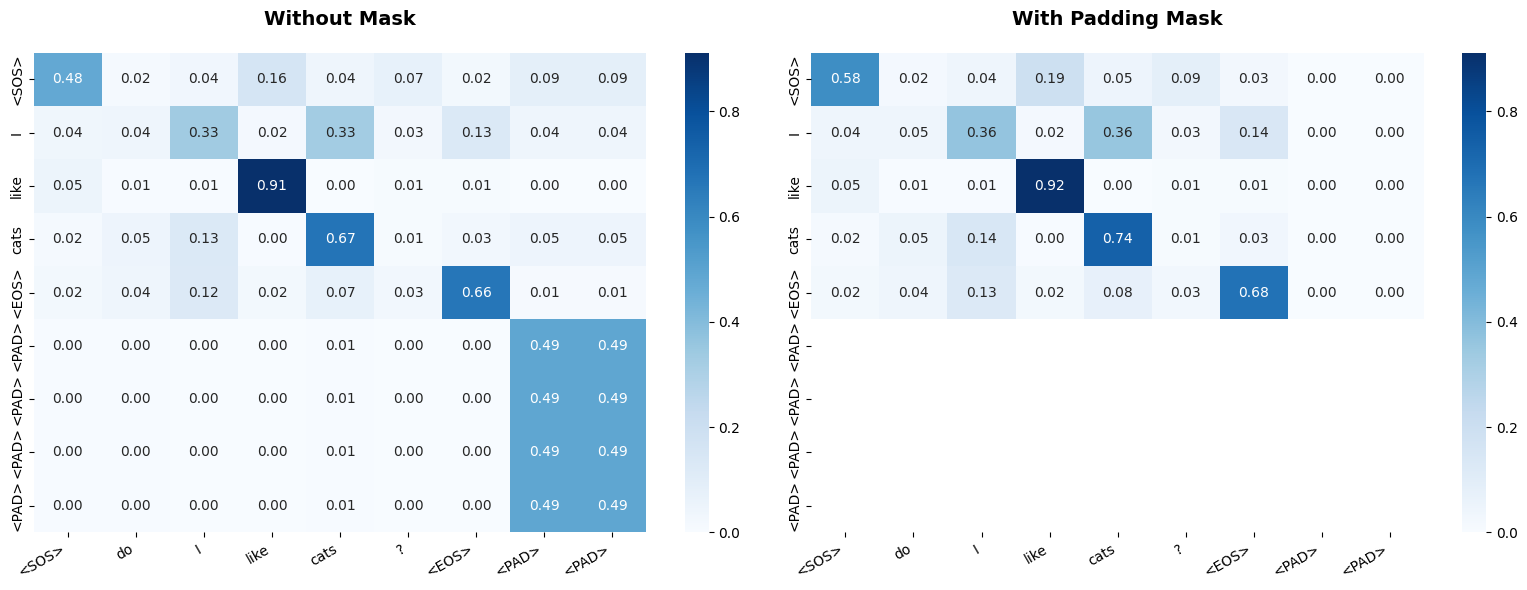

In [8]:
q_pad_mask = create_padding_mask(batch_tokens[0:1])
k_pad_mask = create_padding_mask(batch_tokens[1:2])
combined_mask = q_pad_mask.transpose(-2, -1) * k_pad_mask

_, w_no_mask_raw = scaled_dot_product_attention(Q, K, V, mask=None)
w_no_mask = w_no_mask_raw[0, 0].detach().numpy()

_, w_masked_raw = scaled_dot_product_attention(Q, K, V, mask=combined_mask)
w_masked = w_masked_raw[0, 0].detach().numpy()

tokens_s1 = decode(batch_tokens[1])
tokens_s2 = decode(batch_tokens[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
max_val = max(w_no_mask.max(), w_masked.max())

for ax, data, title in zip(axes, [w_no_mask, w_masked], ['Without Mask', 'With Padding Mask']):
    sns.heatmap(data, 
                annot=True, 
                fmt=".2f", 
                cmap='Blues', 
                vmin=0, vmax=max_val, 
                xticklabels=tokens_s1, 
                yticklabels=tokens_s2, 
                ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

#### 4.2 Causal Mask (Look-Ahead Mask)

Decoder는 토큰을 순서대로 생성합니다.  
위치 $i$의 토큰을 예측할 때, 미래 위치 $j > i$의 정보를 가려야 합니다.

##### 수식
$$\text{CausalMask}_{ij} = \begin{cases} 1 & \text{if } j \le i \\ 0 & \text{if } j > i \end{cases}$$

이는 하삼각 행렬(lower triangular matrix)로 표현됩니다.

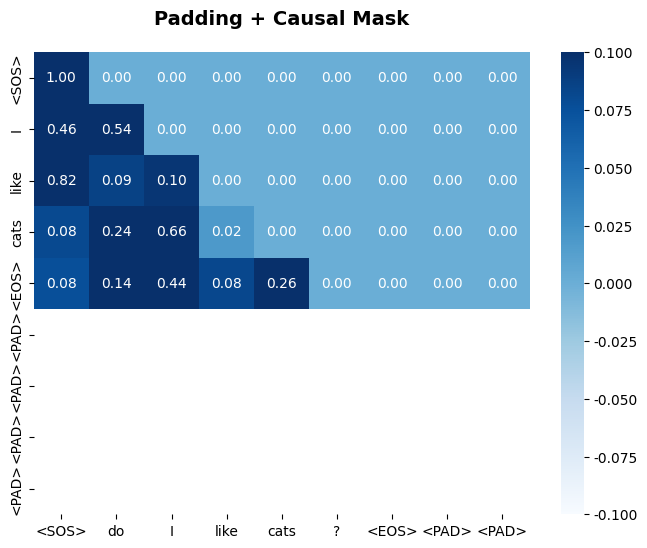

In [9]:
def create_causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len)) # (seq_len, seq_len) 크기의 하삼각 행렬을 생성하여 causal mask를 만듭니다.

causal_mask = create_causal_mask(MAX_SEQ)

combined_mask2 = (causal_mask.bool() & combined_mask.bool()).float()
_, w_masked_raw2 = scaled_dot_product_attention(Q, K, V, mask=combined_mask2)
w_masked2 = w_masked_raw2[0, 0].detach().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(w_masked2, annot=True, fmt=".2f", cmap='Blues', vmin=0, vmax=w_masked2.max(),
            xticklabels=tokens_s1, yticklabels=tokens_s2)
ax.set_title("Padding + Causal Mask", fontsize=14, fontweight='bold', pad=20)
plt.show()

---
### 5. Positional Encoding

Attention은 위치 정보가 없습니다. 순서가 다른 문장의 Attention 결과가 동일할 수 있습니다
따라서 Embedding에 위치 정보를 직접 더 해야합니다.

#### 수식
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

- $pos$: 시퀀스 내 위치 (0, 1, 2, ...)
- $i$: 임베딩 차원 인덱스
- 차원마다 다른 주파수 → 각 위치가 고유한 벡터

In [10]:
def positional_encoding(max_len, d_model):
    PE = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    i   = torch.arange(0, d_model, 2, dtype=torch.float)

    div_term = torch.pow(10000, i / d_model)

    PE[:, 0::2] = torch.sin(pos / div_term)
    PE[:, 1::2] = torch.cos(pos / div_term)
    return PE

PE = positional_encoding(MAX_SEQ, D_MODEL)

print('=== Positional Encoding ===')
print(f'{"":>6}', '  '.join(f'dim{j}' for j in range(D_MODEL)))
print('-' * 101)
for pos in range(MAX_SEQ):
    row = PE[pos].numpy()
    print(f'pos={pos} ', '  '.join(f'{v:6.3f}' for v in row))

=== Positional Encoding ===
       dim0  dim1  dim2  dim3  dim4  dim5  dim6  dim7
-----------------------------------------------------------------------------------------------------
pos=0   0.000   1.000   0.000   1.000   0.000   1.000   0.000   1.000
pos=1   0.841   0.540   0.100   0.995   0.010   1.000   0.001   1.000
pos=2   0.909  -0.416   0.199   0.980   0.020   1.000   0.002   1.000
pos=3   0.141  -0.990   0.296   0.955   0.030   1.000   0.003   1.000
pos=4  -0.757  -0.654   0.389   0.921   0.040   0.999   0.004   1.000
pos=5  -0.959   0.284   0.479   0.878   0.050   0.999   0.005   1.000
pos=6  -0.279   0.960   0.565   0.825   0.060   0.998   0.006   1.000
pos=7   0.657   0.754   0.644   0.765   0.070   0.998   0.007   1.000
pos=8   0.989  -0.146   0.717   0.697   0.080   0.997   0.008   1.000


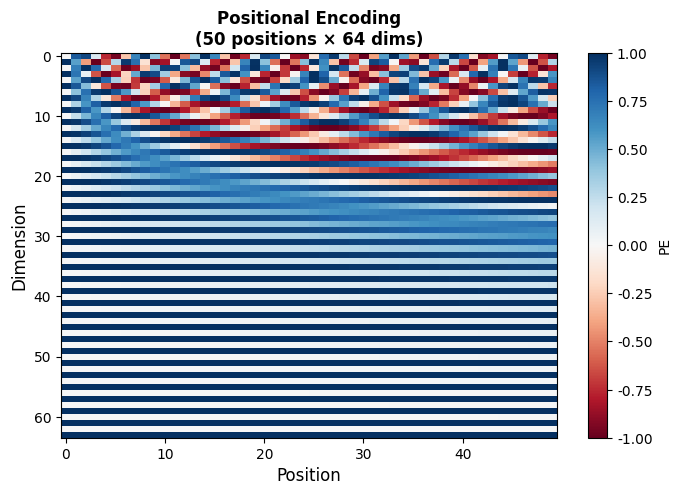

In [11]:
PE_large = positional_encoding(50, 64)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(PE_large.numpy().T, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Dimension', fontsize=12)
ax.set_title('Positional Encoding\n(50 positions × 64 dims)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='PE')

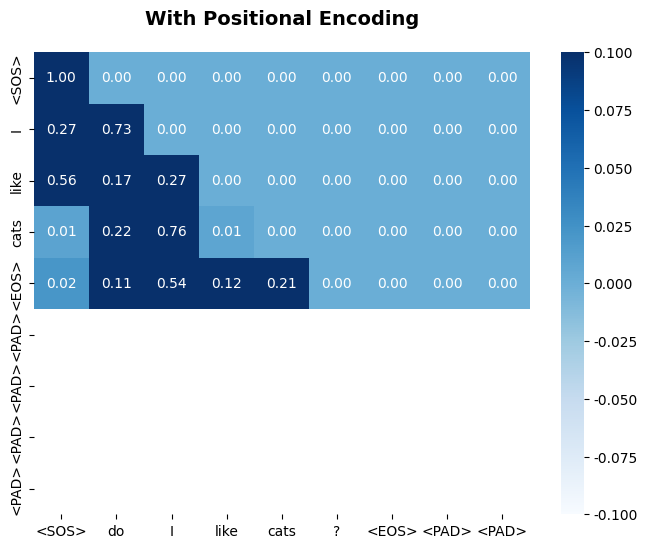

In [12]:
emb_sent1_pe = embedded[0:1] + PE[:embedded.shape[1]].unsqueeze(0)
emb_sent2_pe = embedded[1:2] + PE[:embedded.shape[1]].unsqueeze(0)

Q_pe = emb_sent1_pe.unsqueeze(0)
K_pe = emb_sent2_pe.unsqueeze(0)
V_pe = emb_sent2_pe.unsqueeze(0)

output_pe, attn_weights_pe = scaled_dot_product_attention(Q_pe, K_pe, V_pe, mask=combined_mask2)
attn_weights_pe = attn_weights_pe[0, 0].detach().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(attn_weights_pe, annot=True, fmt=".2f", cmap='Blues', vmin=0, vmax=attn_weights_pe.max(),
            xticklabels=tokens_s1, yticklabels=tokens_s2)
ax.set_title("With Positional Encoding", fontsize=14, fontweight='bold', pad=20)
plt.show()

In [13]:
class PositionEmbedding(nn.Module):
    def __init__(self, vocab_size, max_len, d_model):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        i = torch.arange(0, d_model // 2)

        div_term = torch.pow(10000, (2 * i) / d_model)

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos / div_term)
        pe[:, 1::2] = torch.cos(pos / div_term)

        self.register_buffer("pos_embeddings", pe)

    def forward(self, x):
        word_embeddings = self.embedding(x)  # (B, L, d_model)
        pos_embeddings = self.pos_embeddings[:x.size(1), :].unsqueeze(0)

        return word_embeddings + pos_embeddings

---
### 6. Multi-Head Attention

단일 Attention은 한 번에 하나의 관계만 강조할 수 있습니다.\
다양한 관계를 동시에 충분히 표현하기 위해선 여러 개의 Attention을 병렬로 사용해 서로 다른 관계를 각각 따로 학습해야 합니다.

#### 수식
$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$

- $W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_k}$, 여기서 $d_k = d_{\text{model}} / h$
- $W^O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$

In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.heads = heads
        self.head_dim = d_model // heads
        assert self.head_dim * heads == d_model

        self.values  = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys    = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out  = nn.Linear(d_model, d_model)

    def forward(self, values, keys, queries, mask=None):
        batch_size = queries.shape[0]
        seq_len_v = values.shape[1]
        seq_len_k = keys.shape[1]
        seq_len_q = queries.shape[1]

        values  = values.reshape(batch_size, seq_len_v, self.heads, self.head_dim)
        keys    = keys.reshape(batch_size, seq_len_k, self.heads, self.head_dim)
        queries = queries.reshape(batch_size, seq_len_q, self.heads, self.head_dim)

        values  = self.values(values).permute(0, 2, 1, 3)
        keys    = self.keys(keys).permute(0, 2, 1, 3)
        queries = self.queries(queries).permute(0, 2, 1, 3)

        out, attn_weights = scaled_dot_product_attention(queries, keys, values, mask)

        out_reshaped = out.permute(0, 2, 1, 3).reshape(batch_size, seq_len_q, self.d_model)
        out = self.fc_out(out_reshaped)

        return out, attn_weights

---

### 7. Encoder and Decoder

#### 7.1 Residual Connection

Hidden State가 깊어질수록 **Vanishing Gradient** 문제가 발생합니다.\
Residual Connection은 입력을 출력에 바로 더해, 기울기가 소실을 방지할 수 있습니다.

##### 수식
$$\text{output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

#### 7.2 Layer Normalization

Layer Normalization은 각 레이어의 활성화 값을 정규화하여 학습을 빠르고 안정적으로 만드는 기법입니다. 

##### 수식
$$\text{LayerNorm}(x) = \gamma \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$
(여기서 $\mu$는 각 샘플의 평균, $\sigma^2$은 분산, $\epsilon$은 수치적 안정성을 위한 작은 값입니다.)

#### 7.3 Feed-Forward Networks (FFN)

Attention 이후에는 모든 토큰에 개별적으로 적용되는 완전 연결 피드 포워드 신경망이 위치합니다. \
이는 각 위치에서 독립적으로 계산되므로 "Position-wise"라고 불립니다.

##### 수식
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff, drop_out=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(drop_out)

    def forward(self, value, key, query, mask):
        attention, _ = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))

        out = self.norm2(self.dropout(self.ffn(x) + x))
        return out

In [16]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model, n_layers, heads, d_ff, drop_out=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.embedding = PositionEmbedding(vocab_size, seq_len, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, heads, d_ff, drop_out) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(drop_out)

    def forward(self, X, mask):
        out = self.dropout(self.embedding(X))
        
        for layer in self.layers:
            out = layer(out, out, out, mask)

        return out

In [17]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff, drop_out = 0.1):
        super(DecoderBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, heads)
        self.norm = nn.LayerNorm(d_model)
        self.transformer_block = TransformerBlock(d_model, heads, d_ff, drop_out)
        self.dropout = nn.Dropout(drop_out)

    def forward(self, X, value, key, src_mask, trg_mask):
        attention, _ = self.attention(X, X, X, trg_mask)
        query = self.dropout(self.norm(attention + X))

        out = self.transformer_block(value, key, query, src_mask)
        return out

In [18]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model, n_layers, heads, d_ff, drop_out = 0.1):
        super(Decoder, self).__init__()
        self.embedding = PositionEmbedding(vocab_size, seq_len, d_model)
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, heads, d_ff, drop_out) for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(drop_out)

    def forward(self, X, enc_out, src_mask, trg_mask):
        out = self.dropout(self.embedding(X))

        for layer in self.layers:
            out = layer(out, enc_out, enc_out, src_mask, trg_mask)

        out = self.fc_out(out)
        return out

---
### 8. Transformer

In [19]:
class Transformer(nn.Module):
    def __init__(self, inp_vocab_size, trg_vocab_size, src_pad_idx, trg_pad_idx, d_model, d_ff, device,
                 n_layers=1, heads=1, drop_out=0.1, max_seq_len=MAX_SEQ):
        super(Transformer, self).__init__()

        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device
        self.encoder = Encoder(inp_vocab_size, max_seq_len, d_model, n_layers, heads, 
                               d_ff, drop_out).to(device)
        self.decoder = Decoder(trg_vocab_size, max_seq_len, d_model, n_layers, heads, 
                               d_ff, drop_out).to(device)

    def make_src_mask(self, src):
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask.to(self.device)

    def make_trg_mask(self, trg):
        batch_size, trg_seq_len = trg.shape
        trg_mask = torch.tril(torch.ones((trg_seq_len, trg_seq_len))).expand(
            batch_size, 1, trg_seq_len, trg_seq_len)
        return trg_mask.to(self.device)

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        enc_out = self.encoder(src, src_mask)
        out = self.decoder(trg, enc_out, src_mask, trg_mask)
        return out

---
### 9. Train : Forward Propagation and Backpropagation

#### 역전파 단계
1. **Loss Calculation**: 예측값과 실제 정답(Label) 사이의 오차 계산.
   - Cross-Entropy Loss: $L = -\sum y \log(\hat{y})$
2. **Gradient Computation (Chain Rule)**: 출력층부터 입력층까지 미분을 통해 기울기 계산.
   - $\frac{\partial L}{\partial W}$를 구하기 위해 각 서브레이어(FFN, Attention 등)를 거슬러 올라감.
3. **Weight Update**: 옵티마이저(예: Adam)를 사용하여 가중치 수정.
   - $W_{i+1} = W_{i} - \eta \cdot \nabla W$

In [20]:
def step(model, enc_src, dec_src, trg, loss_fn, vocab, device):
    enc_src = enc_src.to(device)
    dec_src = dec_src.to(device)
    trg = trg.to(device)

    # 순전파
    logits = model(enc_src, dec_src)

    loss = loss_fn(logits.view(-1, logits.shape[-1]), trg.view(-1))
    
    preds = logits.argmax(dim=-1)
    mask = trg != vocab['<PAD>']

    if vocab.get('<SOS>') is not None:
        mask = mask & (trg != vocab['<SOS>'])

    correct_predictions = (preds[mask] == trg[mask]).sum().item()
    total_valid = mask.sum().item()
    accuracy = correct_predictions / total_valid if total_valid > 0 else 0

    return loss, accuracy, " ".join(decode(preds[mask].cpu().numpy())), " ".join(decode(trg[mask].cpu().numpy()))

In [21]:
def train_step(model, iterator, optimizer, loss_fn, clip, VOCAB, device, logging, handle):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for i, batch in enumerate(iterator):
        enc_src, dec_src, trg = batch

        optimizer.zero_grad()

        loss, accuracy, pred, _trg = step(model, enc_src, dec_src, trg, loss_fn, VOCAB, device)

        # 역전파
        loss.backward()

        # 모델의 파라미터 그래디언트가 너무 커지는 것을 방지하기 위해 클리핑을 적용합니다.
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        # Gradient descent
        optimizer.step()

        if i % logging == 0:
                log_text = f"training batch {i}...<br>predictions: {pred}<br>truth: {_trg}"
                handle.update(HTML(log_text))

        epoch_loss += loss.item()
        epoch_acc += accuracy

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [22]:
def evaluate_step(model, iterator, loss_fn, VOCAB, device, logging, handle):
    model.eval()  
    epoch_loss = 0
    epoch_acc = 0

    with torch.no_grad():  
        for i, batch in enumerate(iterator):

            enc_src, dec_src, trg = batch

            loss, accuracy, pred, _trg = step(model, enc_src, dec_src, trg, loss_fn, VOCAB, device)

            if i % logging == 0:
                log_text = f"evaluating batch {i}...<br>predictions: {pred}<br>truth: {_trg}"
                handle.update(HTML(log_text))

            epoch_loss += loss.item()
            epoch_acc += accuracy

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [23]:
def train(model, train_loader, val_loader, optimizer, loss_fn, clip, epochs, VOCAB, device, logging=10):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    handle = display("Initializing log...", display_id=True)

    with tqdm(range(epochs), desc="Training") as pbar:
        for epoch in pbar:
            train_loss, train_acc = train_step(model, train_loader, optimizer, loss_fn, clip, VOCAB, device, logging, handle)

            train_losses.append(train_loss)
            train_accs.append(train_acc)
            result = f'Epoch: {epoch + 1:02} || Train Loss: {train_loss:.3f} | Train Acc: {train_acc * 100:.2f}%'

            if val_loader:
                eval_loss, eval_acc = evaluate_step(model, val_loader, loss_fn, VOCAB, device, logging, handle)
                test_losses.append(eval_loss)
                test_accs.append(eval_acc)

                result += f' || Eval Loss: {eval_loss:.3f} | Eval Acc: {eval_acc * 100:.2f}% ||'

            pbar.set_postfix_str(result)

    return model, train_losses, test_losses, train_accs, test_accs

---
### 10. Training with qa dataset

In [24]:
class QADataset(Dataset):
    def __init__(self, batch_tokens, vocab, max_seq):
        self.data = []
        self.vocab = vocab
        self.idx2word = {v: k for k, v in vocab.items()}
        self.max_seq = max_seq

        all_questions = []
        statements = []
        for seq in batch_tokens:
            if vocab['?'] in seq:
                all_questions.append(seq)
            else:
                statements.append(seq)

        for q_seq in all_questions:
            q_words = [self.idx2word[t.item()] for t in q_seq if t.item() not in 
                       [vocab['<SOS>'], vocab['<EOS>'], vocab['<PAD>'], vocab['do'], vocab['?']]]
            
            if not q_words: continue
            
            target_sub = self._shift_perspective(q_words[0])
            target_obj = self._shift_perspective(q_words[-1])

            for s_seq in statements:
                s_words = [self.idx2word[t.item()] for t in s_seq if t.item() not in 
                           [vocab['<SOS>'], vocab['<EOS>'], vocab['<PAD>'], vocab['do'], vocab['really'], vocab['not']]]
                
                if len(s_words) < 2: continue
                
                curr_sub = s_words[0]
                curr_obj = s_words[-1]

                if curr_sub == target_sub and curr_obj == target_obj:
                    self.data.append((q_seq, s_seq))

    def _shift_perspective(self, word):
        mapping = {'I': 'you', 'you': 'I', 'me': 'you', 'cats': 'cats', 'dogs': 'dogs'}
        return mapping.get(word, word)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        q, a = self.data[idx]
        pad_val = self.vocab['<PAD>']
        
        # 1. Encoder Input: 질문 전체
        enc_input = q
        
        # 2. Decoder Input: <SOS>로 시작하는 답변
        # 보통 모델은 SOS를 보고 첫 단어를 예측하므로 [SOS, A, B] 형태가 필요합니다.
        dec_input = torch.cat([a[:-1], torch.tensor([pad_val])])
        
        # 3. Target: 예측해야 할 정답
        # 모델이 [A, B, EOS]를 순차적으로 맞히도록 설정
        target = torch.cat([a[1:], torch.tensor([pad_val])])

        return enc_input, dec_input, target

In [25]:
qa_dataset = QADataset(batch_tokens, vocab, MAX_SEQ)

print(f"총 생성된 QA 쌍의 수: {len(qa_dataset)}\n")

for i in range(len(qa_dataset)):
    q_tensor, q_tensor2, a_tensor = qa_dataset[i]
    
    q_str = " ".join([idx2word[t.item()] for t in q_tensor if t.item() != vocab['<PAD>']])
    a_str = " ".join([idx2word[t.item()] for t in a_tensor if t.item() != vocab['<PAD>']])
    
    print(f"Q {i+1}: {q_str}")
    print(f"A {i+1}: {a_str}")
    print("-" * 30)

총 생성된 QA 쌍의 수: 1296

Q 1: <SOS> do I like cats ? <EOS>
A 1: you like cats <EOS>
------------------------------
Q 2: <SOS> do I like cats ? <EOS>
A 2: you love cats <EOS>
------------------------------
Q 3: <SOS> do I like cats ? <EOS>
A 3: you hate cats <EOS>
------------------------------
Q 4: <SOS> do I like cats ? <EOS>
A 4: you really like cats <EOS>
------------------------------
Q 5: <SOS> do I like cats ? <EOS>
A 5: you really love cats <EOS>
------------------------------
Q 6: <SOS> do I like cats ? <EOS>
A 6: you really hate cats <EOS>
------------------------------
Q 7: <SOS> do I like cats ? <EOS>
A 7: you do not like cats <EOS>
------------------------------
Q 8: <SOS> do I like cats ? <EOS>
A 8: you do not love cats <EOS>
------------------------------
Q 9: <SOS> do I like cats ? <EOS>
A 9: you do not hate cats <EOS>
------------------------------
Q 10: <SOS> do I like cats ? <EOS>
A 10: you do not really like cats <EOS>
------------------------------
Q 11: <SOS> do I like

In [26]:
dataset_size = len(qa_dataset)
train_size = int(dataset_size * 0.8)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(qa_dataset, [train_size, test_size])

batch_size = 2

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'총 샘플 수: {len(qa_dataset)}')
print(f'훈련 데이터 수: {len(train_dataset)} (배치 수: {len(train_dataloader)})')
print(f'테스트 데이터 수: {len(test_dataset)} (배치 수: {len(test_dataloader)})')

총 샘플 수: 1296
훈련 데이터 수: 1036 (배치 수: 518)
테스트 데이터 수: 260 (배치 수: 130)


In [27]:
d_model = 8
d_ff = d_model * 4
n_layers = 2
heads = 2
drop_out = 0.05

model = Transformer(
    inp_vocab_size=VOCAB_SIZE,
    trg_vocab_size=VOCAB_SIZE,
    src_pad_idx=vocab['<PAD>'],
    trg_pad_idx=vocab['<PAD>'],
    d_model=d_model,
    d_ff=d_ff,
    n_layers=n_layers,
    heads=heads,
    drop_out=drop_out,
    max_seq_len=MAX_SEQ,
    device=device
).to(device)

loss_function = torch.nn.CrossEntropyLoss(ignore_index=vocab['<PAD>'], reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model.parameters())
print(f'\n총 파라미터 수: {total_params:,}')


총 파라미터 수: 3,463


In [28]:
print(model)

Transformer(
  (encoder): Encoder(
    (embedding): PositionEmbedding(
      (embedding): Embedding(15, 8)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerBlock(
        (attention): MultiHeadAttention(
          (values): Linear(in_features=4, out_features=4, bias=False)
          (keys): Linear(in_features=4, out_features=4, bias=False)
          (queries): Linear(in_features=4, out_features=4, bias=False)
          (fc_out): Linear(in_features=8, out_features=8, bias=True)
        )
        (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=8, out_features=32, bias=True)
          (1): ReLU()
          (2): Linear(in_features=32, out_features=8, bias=True)
        )
        (dropout): Dropout(p=0.05, inplace=False)
      )
    )
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (decoder): Decoder(
    (embedding): PositionEmbedding

In [29]:
transformer, train_losses, test_losses, train_accs, test_accs = train(model, train_dataloader, test_dataloader, optimizer, loss_function, clip=1, 
                    epochs=50, VOCAB=vocab, device=device, logging=40)

Training: 100%|██████████| 50/50 [07:31<00:00,  9.02s/it, Epoch: 50 || Train Loss: 0.505 | Train Acc: 78.37% || Eval Loss: 0.459 | Eval Acc: 80.25% ||]


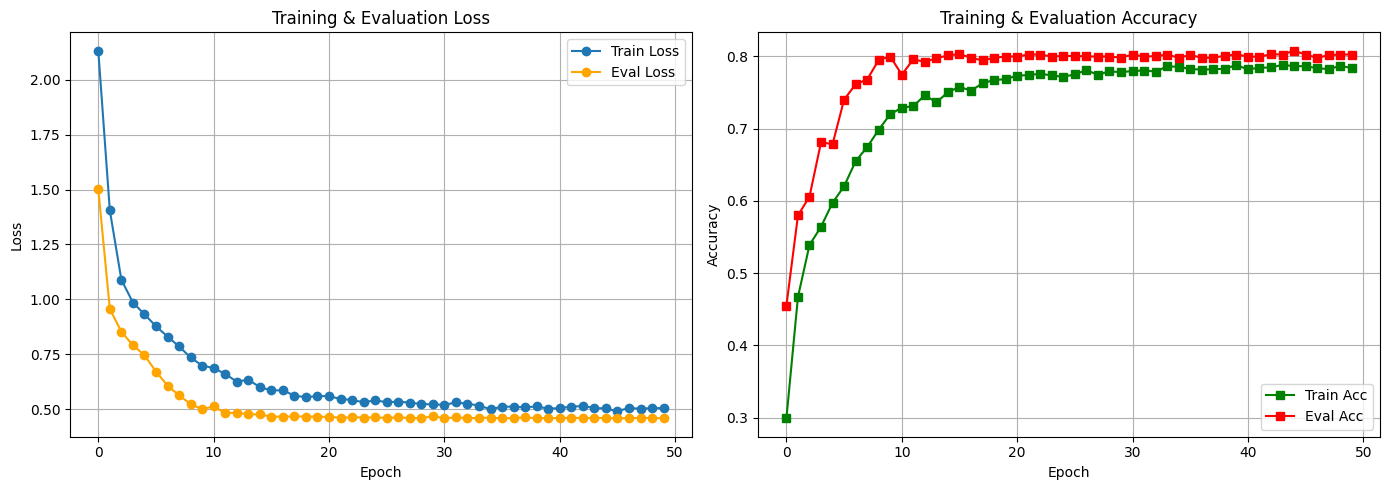

In [30]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
if test_losses:
    plt.plot(test_losses, label='Eval Loss', marker='o', color='orange')
plt.title('Training & Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', marker='s', color='green')
if test_accs:
    plt.plot(test_accs, label='Eval Acc', marker='s', color='red')
plt.title('Training & Evaluation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

loss와 accuracy가 모두 안정적으로 수렴하는 것을 볼 수 있습니다. \
작은 데이터셋과 단순한 모델이지만, 트랜스포머가 학습을 통해 질문에 대한 답변을 생성할 수 있음을 확인할 수 있습니다.

그러나 evalution loss가 train loss보다 낮은 것을 관찰할 수 있습니다.\
대부분의 딥러닝에선 평가 데이터셋은 학습되지 않기 때문에 train loss보다 높게 나오는 것이 일반적입니다.\
생성된 데이터셋을 확인하고 왜 이러한 현상이 생겼는지 분석해봅시다.

데이터셋에서 질문과 답변이 매우 유사한 패턴을 가지고 있다면 모델이 훈련 데이터에서 학습한 패턴이 평가 데이터에서도 잘 작동할 수 있습니다.\
따라서 평가 데이터셋이 훈련 데이터셋과 **유사한 분포**를 가지고 있을 가능성이 높습니다.\
이는 하나의 질문에 여러 비슷한 답변이 존재하기 때문에 train 데이터가 eval 데이터를 포함한다고 볼 수 있습니다.\
따라서 이는 좋지 못한 데이터셋입니다. 

실제 모델에 학습되는 NLP 데이터셋 또한 하나의 질문에 여러개의 답변이 존재할 수 있는데 왜 이러한 현상이 관찰되지 않는지 생각해봅시다.\
실제 NLP 데이터셋에서는 질문과 답변이 더 다양하고 복잡한 패턴을 가지고 있습니다.

**① 조건부 엔트로피 (Conditional Entropy)**  
실제 언어 데이터는 입력 $x$에 대해 가능한 답변 $y$의 분포가 매우 넓습니다.
$$H(Y|X) = -\sum_{x \in \mathcal{X}, y \in \mathcal{Y}} p(x, y) \log p(y|x)$$
실제 데이터셋은 이 엔트로피 수치가 매우 높기 때문에, 모델이 훈련 데이터의 특정 패턴($p(y|x)$)을 완벽히 학습하더라도 평가 데이터의 미세한 문맥 차이를 다 담아내지 못합니다.

**② 일반화 갭 (Generalization Gap)**  
모델의 손실 함수를 $\mathcal{L}$이라 할 때, 두 손실의 차이는 다음과 같습니다.
$$\text{Gap} = \mathbb{E}_{(x,y) \sim \mathcal{D}_{eval}} [\mathcal{L}(f(x), y)] - \mathbb{E}_{(x,y) \sim \mathcal{D}_{train}} [\mathcal{L}(f(x), y)]$$
실제 데이터는 $\mathcal{D}_{train}$과 $\mathcal{D}_{eval}$ 사이의 분산이 크기 때문에 일반화 오차가 발생하지만, 현재의 단순한 데이터셋은 두 분포가 거의 일치하여 이 갭이 0보다 작아지는 수치적 역전이 발생합니다.

따라서 모델이 훈련 데이터에서 학습한 패턴이 평가 데이터에서 잘 작동하지 않을 수 있습니다.

이는 텍스트 생성의 품질을 다각도로 평가할 수 있는 지표들이 필요함을 시사합니다.\
정확도 이외의 댜른 평가 지표 (ex. BLEU, ROUGE, METEOR 등)은 다음 시간에 다뤄보겠습니다.

---

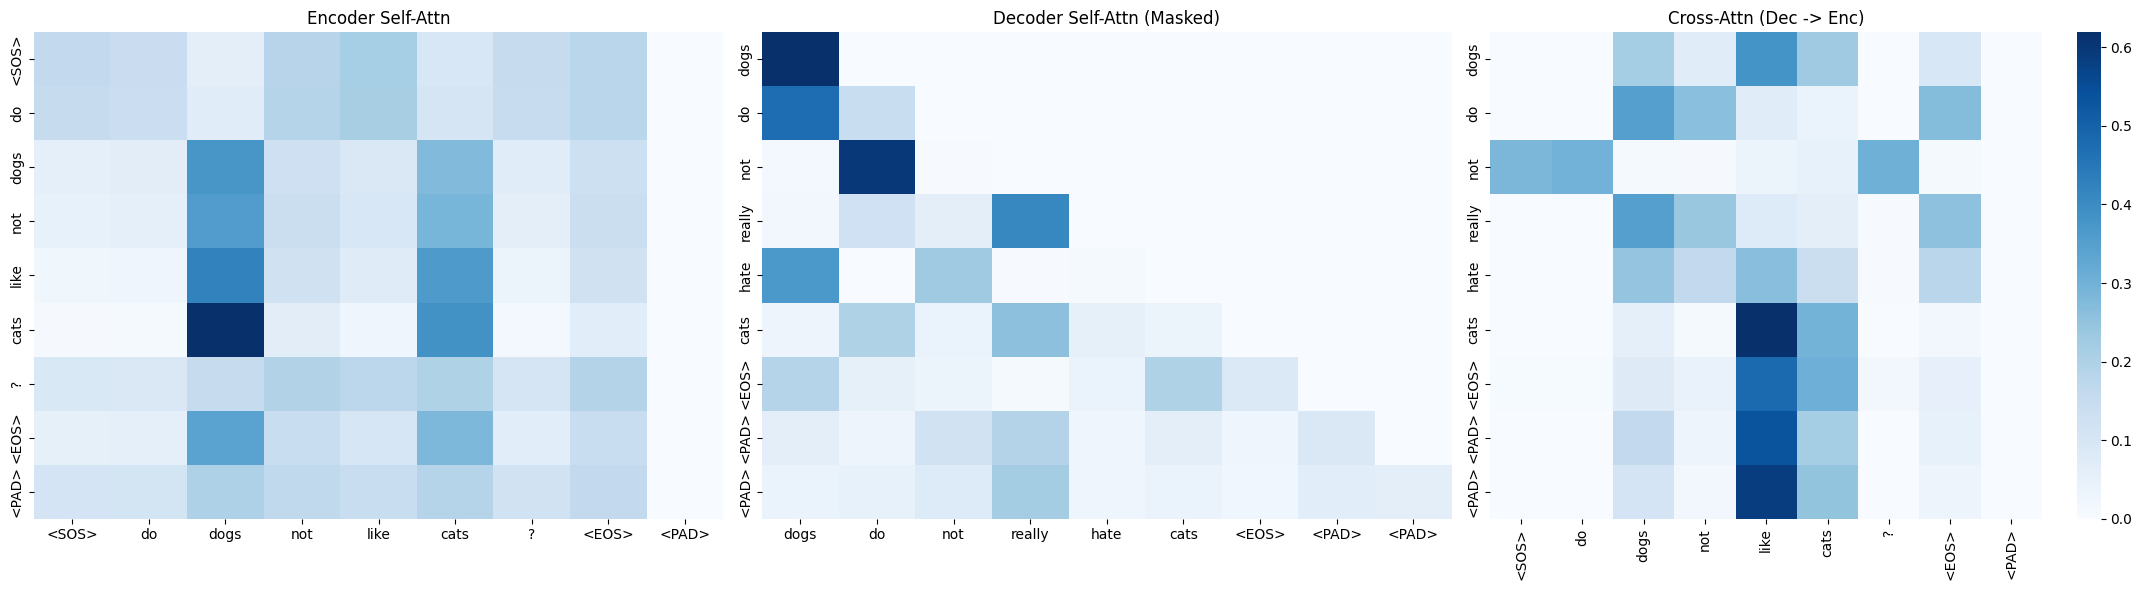

In [31]:
attentions = {}
hooks = []

def get_attention(name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            attentions[name] = output[1].detach().cpu()
    return hook

def register_hooks(model):
    for h in hooks: h.remove()
    hooks.clear()
    
    # 1. Encoder Self-Attention
    hooks.append(model.encoder.layers[-1].attention.register_forward_hook(get_attention('enc_self')))
    
    # 2. Decoder Self-Attention
    hooks.append(model.decoder.layers[-1].attention.register_forward_hook(get_attention('dec_self')))
    
    # 3. Decoder Cross-Attention
    hooks.append(model.decoder.layers[-1].transformer_block.attention.register_forward_hook(get_attention('cross')))

def plot_transformer_attention(src_tokens, tgt_tokens):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    src_labels = decode(src_tokens)
    tgt_labels = decode(tgt_tokens)
    
    plot_configs = [
        ('enc_self', src_labels, src_labels, 'Encoder Self-Attn'),
        ('dec_self', tgt_labels, tgt_labels, 'Decoder Self-Attn (Masked)'),
        ('cross', src_labels, tgt_labels, 'Cross-Attn (Dec -> Enc)')
    ]

    for i, (key, x_labels, y_labels, title) in enumerate(plot_configs):
        if key in attentions:

            attn_data = attentions[key][0, 0].numpy() 
            
            sns.heatmap(attn_data, xticklabels=x_labels, yticklabels=y_labels, 
                        cmap='Blues', ax=axes[i], cbar=(i==2))
            axes[i].set_title(title)

    plt.tight_layout()
    plt.show()

register_hooks(transformer)
    
src_tokens, _, tgt_tokens = test_dataset.__getitem__(0)

logits = transformer(src_tokens.unsqueeze(0).to(device), tgt_tokens.unsqueeze(0).to(device))

plot_transformer_attention(src_tokens, tgt_tokens)

for h in hooks: h.remove()

In [32]:
probs = F.softmax(logits[0], dim=-1)

for i, prob in enumerate(probs):
    token = tgt_tokens[i].item()
    token_str = idx2word.get(token, "<UNK>")
    print(f"Token: {token_str}, Probability: {prob.max().item():.4f}")

Token: dogs, Probability: 0.6625
Token: do, Probability: 0.9999
Token: not, Probability: 0.4638
Token: really, Probability: 0.3412
Token: hate, Probability: 0.9999
Token: cats, Probability: 1.0000
Token: <EOS>, Probability: 0.9991
Token: <PAD>, Probability: 0.9999
Token: <PAD>, Probability: 1.0000


------------------------------
Input Sentence:    <SOS> do you really hate me ? <EOS>
Target Sentence:   I really like you <EOS>
Generated Sentence: <SOS> I do not really hate you <EOS>
------------------------------


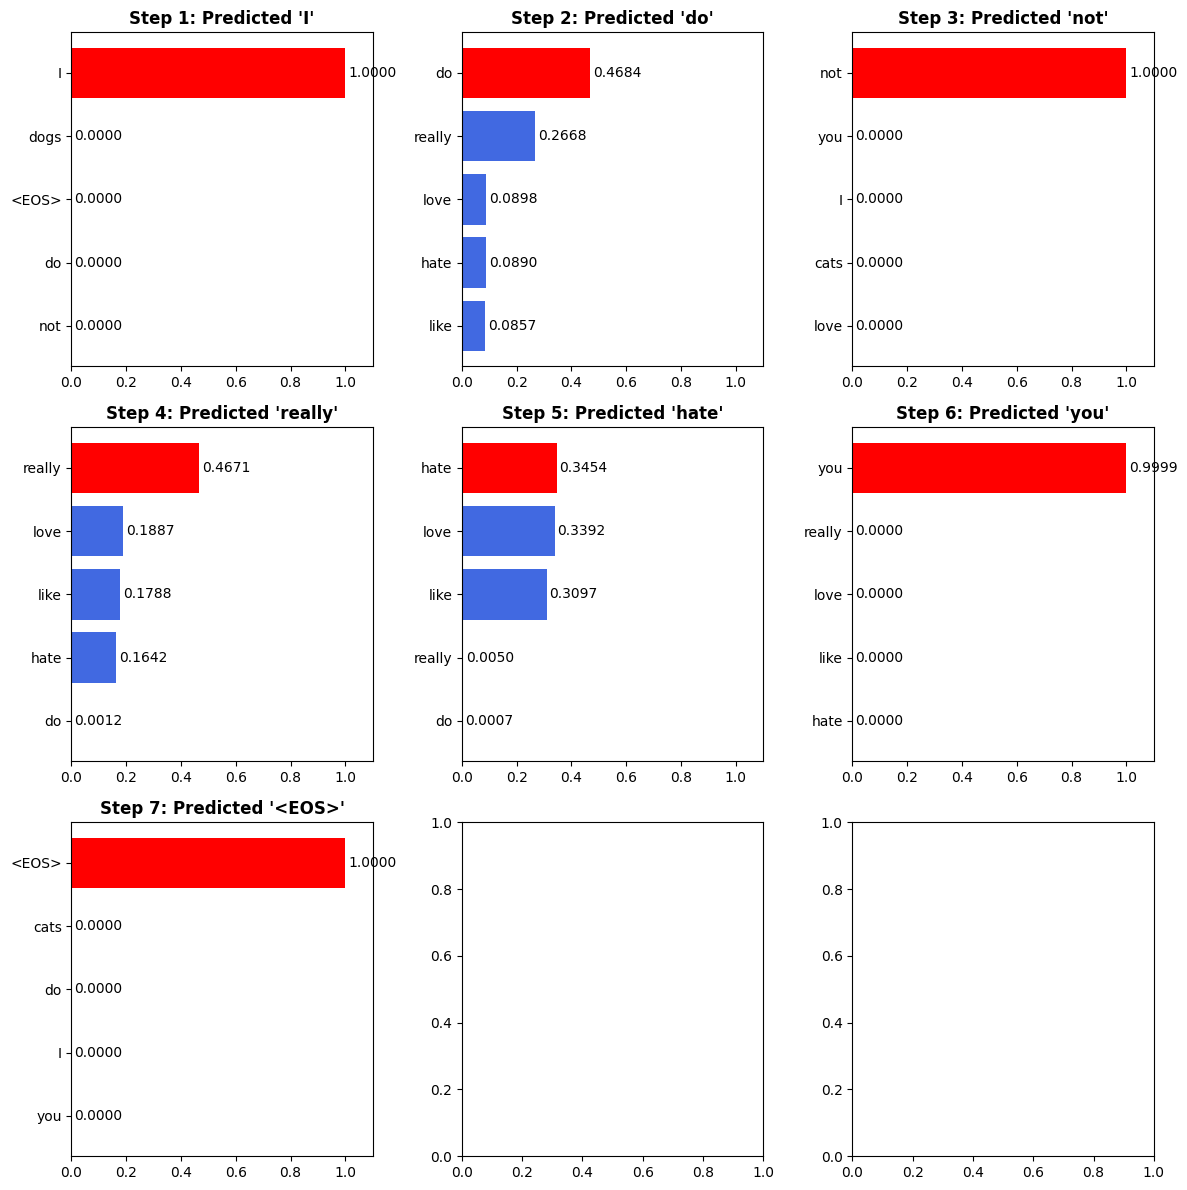

In [33]:
def generate_sequence(model, src_tokens, max_len=50, eos_token=2, top_k=5, VOCAB=None, device='cuda'):
    model.eval()

    if src_tokens.dim() == 1:
        src_tokens = src_tokens.unsqueeze(0)
    
    src_tokens = src_tokens.to(device)
    trg_tokens = torch.tensor([[VOCAB['<SOS>']]]).to(device) # 시작은 <SOS> 토큰으로 시작합니다.

    selected_info = []  # 각 단계별 Top-K

    for _ in range(max_len):
        with torch.no_grad():
            logits = model(src_tokens, trg_tokens)
        
        probs = F.softmax(logits[:, -1, :], dim=-1)

        top_k_probs, top_k_indices = torch.topk(probs, top_k, dim=-1)
        
        selected_info.append({
            'indices': top_k_indices.squeeze(0).cpu().numpy(),
            'probs': top_k_probs.squeeze(0).cpu().numpy()
        })

        next_token = top_k_indices[:, 0].unsqueeze(1) 
        trg_tokens = torch.cat([trg_tokens, next_token], dim=1)

        # <EOS> 토큰 생성 시 중단
        if next_token.item() == eos_token:
            break
    
    return trg_tokens, selected_info

def plot_step_visualizations(selected_info, vocab):
    num_steps = len(selected_info)
    cols = 3
    rows = math.ceil(num_steps / cols)
    _, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if num_steps > 1 else [axes]
    
    if num_steps == 1:
        axes = [axes]

    for i, info in enumerate(selected_info):
        indices = info['indices']
        probs = info['probs']
        words = [vocab.get(idx, f"ID:{idx}") for idx in indices]

        colors = ['red' if j == 0 else 'royalblue' for j in range(len(indices))]
        
        axes[i].barh(words, probs, color=colors)
        axes[i].set_title(f"Step {i+1}: Predicted '{words[0]}'", fontweight='bold')
        axes[i].set_xlim(0, 1.1)
        axes[i].invert_yaxis()

        for j, p in enumerate(probs):
            axes[i].text(p + 0.01, j, f'{p:.4f}', va='center')

    plt.tight_layout()
    plt.show()

src_tokens, _, tgt_tokens = test_dataset.__getitem__(30) 
device = next(transformer.parameters()).device

generated_tokens, selected_info = generate_sequence(
    transformer, 
    src_tokens, 
    max_len=20, 
    eos_token=vocab['<EOS>'], 
    top_k=5, 
    VOCAB=vocab, 
    device=device
)

print("-" * 30)
input_sentence = [idx2word.get(t.item(), "<UNK>") for t in src_tokens if t.item() != vocab['<PAD>']]
print("Input Sentence:   ", " ".join(input_sentence))
target_sentence = [idx2word.get(t.item(), "<UNK>") for t in tgt_tokens if t.item() != vocab['<PAD>']]
print("Target Sentence:  ", " ".join(target_sentence))
generated_sentence = [idx2word.get(t.item(), "<UNK>") for t in generated_tokens[0]]
print("Generated Sentence:", " ".join(generated_sentence))
print("-" * 30)

plot_step_visualizations(selected_info, idx2word)

In [38]:
emb = model.encoder.embedding.embedding.weight.data  # (15, 8)

def vec(word):
    return emb[vocab[word]]

def l2_norm(v):
    return torch.norm(v).item()

tests = [
    ("not + love - hate", vec("not") + vec("love") - vec("hate")),
    ("not + like - hate", vec("not") + vec("like") - vec("hate")),
    ("really + like - love", vec("really") + vec("like") - vec("love")),
    ("love - hate", vec("love") - vec("hate")),
    ("not + like - love", vec("not") + vec("like") - vec("love")),
]
print("=== L2 norm ===\n")
results = []
for name, v in tests:
    norm = l2_norm(v)
    results.append((name, norm))
    #print(f"{name:30s} -> {norm:.4f}")

for name, norm in sorted(results, key=lambda x: x[1]):
    print(f"{name:30s} -> {norm:.4f}")

print("\n벡터 연산 결과가 단어 간 의미적 관계를 어느 정도 반영하지 못하고 있음을 확인할 수 있습니다.")
print("이는 모델이 충분히 학습되지 않았기 때문일 수 있습니다.")
print("하지만 단어 임베딩이 초기화된 상태에서도 단어 간의 관계가 완전히 무작위적이지는 않다는 점을 보여줍니다.")
print("예를 들어, 'love - hate' 벡터가 'not + like - love' 벡터보다 L2 norm이 더 작게 나오는 것은 흥미로운 현상입니다.\n"
      "이는 'love'와 'hate'가 모델의 초기 임베딩 공간에서 서로 더 가깝게 위치할 수 있음을 시사합니다.\n")

print("실제 트랜스포머 모델은 임베딩 차원을 512 ~ 1024로 설정하는 경우가 많으며, 충분한 학습을 거치면 단어 간의 의미적 관계를 더 잘 반영하는 벡터 공간이 형성됩니다.")

=== L2 norm ===

love - hate                    -> 3.9095
really + like - love           -> 4.0311
not + like - love              -> 4.3119
not + love - hate              -> 4.6509
not + like - hate              -> 5.4681

벡터 연산 결과가 단어 간 의미적 관계를 어느 정도 반영하지 못하고 있음을 확인할 수 있습니다.
이는 모델이 충분히 학습되지 않았기 때문일 수 있습니다.
하지만 단어 임베딩이 초기화된 상태에서도 단어 간의 관계가 완전히 무작위적이지는 않다는 점을 보여줍니다.
예를 들어, 'love - hate' 벡터가 'not + like - love' 벡터보다 L2 norm이 더 작게 나오는 것은 흥미로운 현상입니다.
이는 'love'와 'hate'가 모델의 초기 임베딩 공간에서 서로 더 가깝게 위치할 수 있음을 시사합니다.

실제 트랜스포머 모델은 임베딩 차원을 512 ~ 1024로 설정하는 경우가 많으며, 충분한 학습을 거치면 단어 간의 의미적 관계를 더 잘 반영하는 벡터 공간이 형성됩니다.


---